In [1]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
sim = AerSimulator(method='statevector')

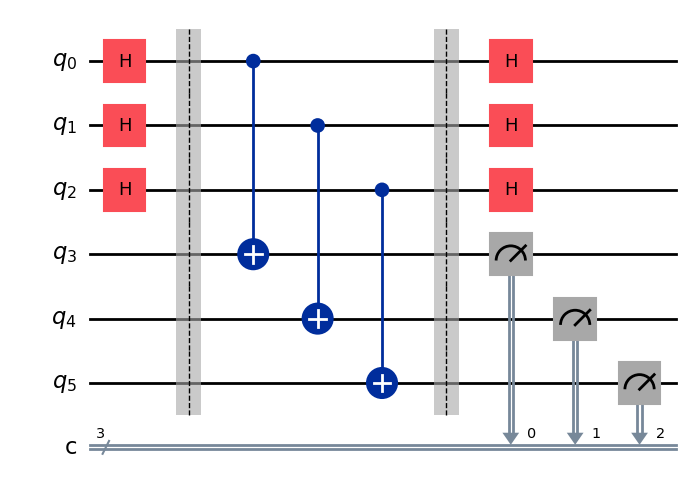

In [2]:
# Simon circuit
n = int(input("Enter number of input qubits: "))
m=n
secret = input(f"Enter {n}-bit secret string: ")

if len(secret) != n or any(bit not in "01" for bit in secret):
    print("Invalid secret")
    exit()

circuit = QuantumCircuit(n+m, n)

# Step 1: Hadamard on input register
circuit.h(range(n))

circuit.barrier()

# =====================
# Simon Oracle U_f
# =====================

# Copy x to output register
for i in range(n):
    circuit.cx(i, i+n)

# Introduce hidden period s
secret = secret[::-1]     # little-endian

first_one = secret.find('1')

if first_one != -1:
    for i in range(first_one+1, n):
        if secret[i] == '1':
            circuit.cx(first_one, i+n)

circuit.barrier()

# Step 2: Hadamard again
circuit.h(range(n))

# Measurement
circuit.measure(range(n,m+n), range(m))

circuit.draw('mpl', filename='simon_circuit.png')

In [3]:
result = sim.run(transpile(circuit, sim), shots=1024).result()
counts = result.get_counts()
print("Measurement results:", counts)

Measurement results: {'101': 123, '001': 157, '100': 132, '000': 121, '010': 113, '110': 120, '111': 125, '011': 133}


In [4]:
from qiskit_ibm_runtime import SamplerV2 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


In [5]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Load IBM account
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Select least busy real device
backend = service.least_busy(
    simulator=False,
    operational=True
)

print("Running on:", backend.name)

# Transpile circuit for target backend
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuit = pm.run(circuit)

# Create sampler
sampler = SamplerV2(mode=backend)

# Run job
job = sampler.run([isa_circuit], shots=1024)

print("Job ID:", job.job_id())

result = job.result()

# Extract counts
counts = result[0].data.c.get_counts()

print("Measurement results:")
print(counts)


qiskit_runtime_service.__init__:WARNING:2026-06-24 12:51:05,191: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-24 12:51:05,493: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-24 12:51:07,660: Using instance: open-instance, plan: open


Running on: ibm_kingston
Job ID: d8u0lvcbp3hs73858l1g
Measurement results:
{'100': 134, '001': 126, '011': 125, '101': 135, '010': 119, '110': 131, '111': 124, '000': 130}


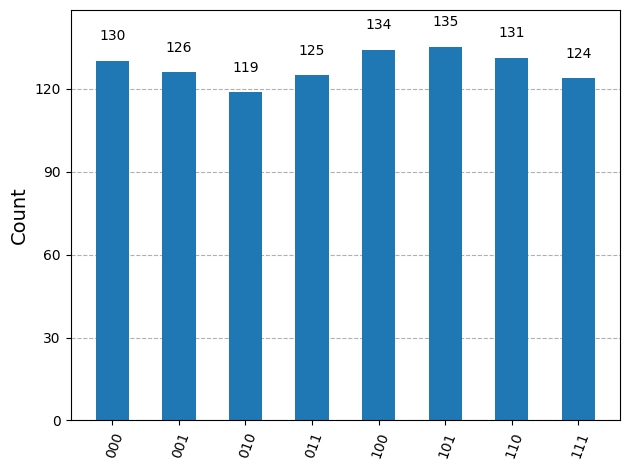

In [6]:
plot_histogram(counts)